In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/playground-series-s6e8/sample_submission.csv
/kaggle/input/competitions/playground-series-s6e8/train.csv
/kaggle/input/competitions/playground-series-s6e8/test.csv


In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

Todo: 
1. Import Training Dataset
2. Conduct Exploratory Data Analysis
3. Remove any columns that aren't needed and create a new dataset
4. Decide which Model to use 

# Importing, Formatting and Cleaning Data


In [3]:
#import training data
train_df = pd.read_csv("/kaggle/input/competitions/playground-series-s6e8/train.csv")
train_df

,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label
0,0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,Male,Medium,No,1
1,1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,Female,Medium,No,0
2,2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,Female,Low,Yes,0
3,3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,Other,Low,NaN,1
4,4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,Female,Medium,No,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
691364,691364,22.0,10.78,3.25,1.57,1.65,7.71,86.0,94.0,12.89,Male,NaN,No,1
691365,691365,20.0,3.45,1.86,0.89,0.30,6.59,221.0,42.0,8.47,Female,High,No,1
691366,691366,NaN,NaN,NaN,NaN,2.06,6.16,NaN,86.0,7.79,Other,Medium,No,1
691367,691367,22.0,11.78,3.69,0.23,1.35,5.53,171.0,62.0,7.71,Other,NaN,NaN,1


In [4]:
train_df.describe()

,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,addicted_label
count,691369.000000,662440.000000,595515.000000,557374.000000,564548.000000,639851.000000,646889.000000,623785.000000,610659.000000,579306.000000,691369.000000
mean,345684.000000,26.615408,7.640865,2.471038,1.459265,2.366971,6.804334,145.894900,102.636781,9.479866,0.709424
std,199581.183466,5.153162,2.721446,1.316137,0.934552,1.258797,1.234512,65.917556,48.093970,2.856006,0.454028
min,0.000000,18.000000,0.500000,0.000000,0.000000,0.000000,4.500000,20.000000,15.000000,0.510000,0.000000
25%,172842.000000,22.000000,5.480000,1.450000,0.700000,1.360000,5.780000,93.000000,64.000000,7.280000,0.000000
50%,345684.000000,27.000000,7.770000,2.310000,1.330000,2.200000,6.800000,150.000000,104.000000,9.580000,1.000000
75%,518526.000000,31.000000,9.840000,3.370000,2.090000,3.200000,7.870000,204.000000,145.000000,11.750000,1.000000
max,691368.000000,35.000000,15.000000,8.000000,4.000000,6.000000,9.000000,250.000000,180.000000,17.560000,1.000000


In [5]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 691369 entries, 0 to 691368
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       691369 non-null  int64  
 1   age                      662440 non-null  float64
 2   daily_screen_time_hours  595515 non-null  float64
 3   social_media_hours       557374 non-null  float64
 4   gaming_hours             564548 non-null  float64
 5   work_study_hours         639851 non-null  float64
 6   sleep_hours              646889 non-null  float64
 7   notifications_per_day    623785 non-null  float64
 8   app_opens_per_day        610659 non-null  float64
 9   weekend_screen_time      579306 non-null  float64
 10  gender                   662335 non-null  object 
 11  stress_level             636221 non-null  object 
 12  academic_work_impact     647145 non-null  object 
 13  addicted_label           691369 non-null  int64  
dtypes: f

In [6]:
train_df_viz = train_df.drop('id', axis=1)


<Axes: >

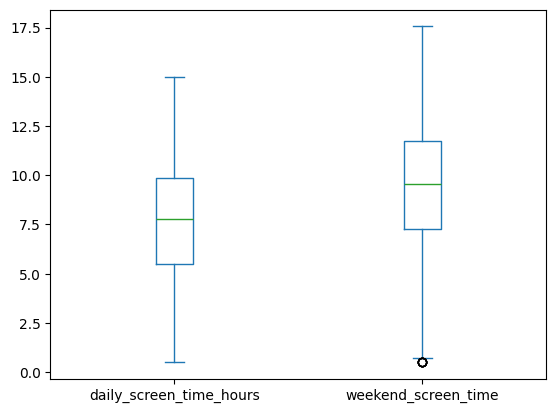

In [7]:
train_df_viz.plot.box(column=['daily_screen_time_hours', 'weekend_screen_time'])

<Axes: >

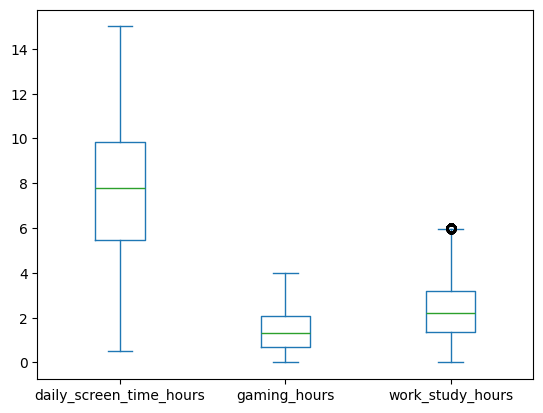

In [8]:
train_df_viz.plot.box(column=['daily_screen_time_hours', 'gaming_hours', 'work_study_hours',  ])

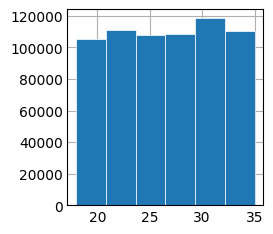

In [9]:
plt.style.use('_mpl-gallery')

x = train_df_viz['age']
# plot:
fig, ax = plt.subplots()

ax.hist(x, bins=6, linewidth=0.5, edgecolor="white")


plt.show()



In [10]:
#Drop rows with missing data
#train_df = train_df.dropna().reset_index(drop=True)
#train_df

In [11]:
#import test set as test_df 
test_df = pd.read_csv("/kaggle/input/competitions/playground-series-s6e8/test.csv")

In [12]:
test_df

,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact
0,691369,30.0,9.34,NaN,0.77,4.09,7.15,153.0,16.0,NaN,Other,Medium,Yes
1,691370,NaN,NaN,1.91,NaN,1.20,8.67,239.0,148.0,10.68,Female,High,No
2,691371,26.0,8.48,3.64,NaN,3.39,7.47,106.0,123.0,NaN,Male,NaN,No
3,691372,20.0,8.37,2.99,1.69,2.53,5.45,178.0,55.0,9.88,Male,High,Yes
4,691373,25.0,8.25,4.02,1.21,2.32,8.46,63.0,86.0,10.72,Male,Low,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...
296297,987666,25.0,11.76,5.15,1.94,2.75,8.24,237.0,127.0,14.10,Male,NaN,NaN
296298,987667,28.0,7.67,2.70,1.55,2.95,5.54,187.0,121.0,8.25,Male,Low,Yes
296299,987668,33.0,5.27,1.84,0.20,2.44,8.29,96.0,73.0,6.57,Female,High,No
296300,987669,NaN,NaN,1.25,0.52,0.71,6.27,57.0,38.0,7.19,Female,Low,Yes


In [13]:
#drop rows with missing values 

#test_df = test_df.dropna().reset_index(drop=True)
#test_df

In [14]:
from sklearn.preprocessing import OneHotEncoder
##IMPORTANT###
#convert categories to numerical (fit on train, transform on test)
categorical_columns = train_df.select_dtypes(include=['object']).columns
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoder.fit(train_df[categorical_columns])

# transform train
encoded_train = encoder.transform(train_df[categorical_columns])
encoded_train_df = pd.DataFrame(
    encoded_train,
    columns=encoder.get_feature_names_out(categorical_columns),
    index=train_df.index
)
final_train_df = pd.concat(
    [train_df.drop(columns=categorical_columns), encoded_train_df],
    axis=1
)

# transform test with the SAME fitted encoder
encoded_test = encoder.transform(test_df[categorical_columns])
encoded_test_df = pd.DataFrame(
    encoded_test,
    columns=encoder.get_feature_names_out(categorical_columns),
    index=test_df.index
)
final_test_df = pd.concat(
    [test_df.drop(columns=categorical_columns), encoded_test_df],
    axis=1
)

train_df = final_train_df
test_df = final_test_df

In [15]:
#Fill in MIssing data on all rows with Mean, Median, 
x = "mean" 
y = "median"
for col in final_train_df.columns:
    if final_train_df[col].isna().any():
        if pd.api.types.is_numeric_dtype(final_train_df[col]):
            final_train_df[col] = final_train_df[col].fillna(final_train_df[col].median())
        else:
            final_train_df[col] = final_train_df[col].fillna(final_train_df[col].mode()[0])

In [16]:
final_train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 691369 entries, 0 to 691368
Data columns (total 22 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   id                        691369 non-null  int64  
 1   age                       691369 non-null  float64
 2   daily_screen_time_hours   691369 non-null  float64
 3   social_media_hours        691369 non-null  float64
 4   gaming_hours              691369 non-null  float64
 5   work_study_hours          691369 non-null  float64
 6   sleep_hours               691369 non-null  float64
 7   notifications_per_day     691369 non-null  float64
 8   app_opens_per_day         691369 non-null  float64
 9   weekend_screen_time       691369 non-null  float64
 10  addicted_label            691369 non-null  int64  
 11  gender_Female             691369 non-null  float64
 12  gender_Male               691369 non-null  float64
 13  gender_Other              691369 non-null  f

In [17]:
final_train_df.describe()

,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,...,gender_Male,gender_Other,gender_nan,stress_level_High,stress_level_Low,stress_level_Medium,stress_level_nan,academic_work_impact_No,academic_work_impact_Yes,academic_work_impact_nan
count,691369.000000,691369.000000,691369.000000,691369.000000,691369.000000,691369.000000,691369.000000,691369.000000,691369.000000,691369.000000,...,691369.000000,691369.000000,691369.000000,691369.000000,691369.000000,691369.000000,691369.000000,691369.000000,691369.000000,691369.000000
mean,345684.000000,26.631501,7.658769,2.439827,1.435553,2.354529,6.804055,146.296189,102.795922,9.496097,...,0.323506,0.313983,0.041995,0.319472,0.300538,0.300223,0.079766,0.457902,0.478133,0.063966
std,199581.183466,5.044786,2.526149,1.183446,0.845979,1.211782,1.194140,62.624733,45.201764,2.614576,...,0.467814,0.464110,0.200578,0.466272,0.458493,0.458355,0.270931,0.498225,0.499522,0.244692
min,0.000000,18.000000,0.500000,0.000000,0.000000,0.000000,4.500000,20.000000,15.000000,0.510000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,172842.000000,22.000000,5.830000,1.660000,0.830000,1.420000,5.860000,102.000000,68.000000,7.720000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,345684.000000,27.000000,7.770000,2.310000,1.330000,2.200000,6.800000,150.000000,104.000000,9.580000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,518526.000000,31.000000,9.560000,3.100000,1.900000,3.110000,7.780000,197.000000,139.000000,11.340000,...,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000
max,691368.000000,35.000000,15.000000,8.000000,4.000000,6.000000,9.000000,250.000000,180.000000,17.560000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [18]:
for col in final_test_df.columns:
    if final_test_df[col].isna().any():
        if pd.api.types.is_numeric_dtype(final_test_df[col]):
            final_test_df[col] = final_test_df[col].fillna(final_test_df[col].median())
        else:
            final_test_df[col] = final_test_df[col].fillna(final_test_df[col].mode()[0])

In [19]:
#Standardize the data
X= final_train_df.drop('addicted_label', axis=1)
y = final_train_df['addicted_label'] #what we will predict

scaler = StandardScaler()
X_scaled = scaler.fit_transform(final_train_df)
X_train=X_scaled
X_train

array([[-1.7320483 , -0.52162822,  0.04403181, ...,  1.08806025,
        -0.95718089, -0.26141362],
       [-1.73204329, -1.51275131, -0.66851585, ...,  1.08806025,
        -0.95718089, -0.26141362],
       [-1.73203828, -1.71097593, -1.01687248, ..., -0.91906675,
         1.0447346 , -0.26141362],
       ...,
       [ 1.73203828,  0.07304564,  0.04403181, ...,  1.08806025,
        -0.95718089, -0.26141362],
       [ 1.73204329, -0.91807746,  1.63142964, ..., -0.91906675,
        -0.95718089,  3.82535539],
       [ 1.7320483 , -1.11630208, -0.79914958, ..., -0.91906675,
         1.0447346 , -0.26141362]])

In [20]:
# Test Scaler
scaler = StandardScaler()
X_scaled1 = scaler.fit_transform(final_test_df)
X_test=X_scaled1
X_test

array([[-1.73204496,  0.67334094,  0.65536099, ..., -0.89563339,
         1.06600758, -0.30831544],
       [-1.73203327,  0.07369239,  0.0447022 , ...,  1.11652827,
        -0.93807963, -0.30831544],
       [-1.73202158, -0.12619046,  0.32086   , ...,  1.11652827,
        -0.93807963, -0.30831544],
       ...,
       [ 1.73202158,  1.27298949, -0.9276844 , ...,  1.11652827,
        -0.93807963, -0.30831544],
       [ 1.73203327,  0.07369239,  0.0447022 , ..., -0.89563339,
         1.06600758, -0.30831544],
       [ 1.73204496,  0.67334094, -0.37925836, ..., -0.89563339,
         1.06600758, -0.30831544]])

# Feature Engineering with Principal Component Analysis 

In [21]:
#pca = PCA(n_components=2)
#X_pca = pca.fit_transform(X_train)


X_train, X_test, y_train, y_test = train_test_split(X_train, y, test_size=0.3, random_state=42)
model = LogisticRegression()
model.fit(X_train, y_train)



LogisticRegression()

In [22]:
#Y_pca = pca.fit_transform(X_test)
#Y_pca

In [23]:
cm = confusion_matrix (X_test, y_test)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['addicted_label'], yticklabels=['addicted_label'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

ValueError: Classification metrics can't handle a mix of continuous-multioutput and binary targets

In [ ]:
from sklearn import metrics
#use model to predict probability that given y value is 1
y_pred_proba = model.predict_proba(X_train)[::,1]

#calculate AUC of model
auc = metrics.roc_auc_score(y_train, y_pred_proba)
print(y_train)
print(y_pred_proba)
#print AUC score
print(auc)

AUC with Mean, No dropped Columnas 
0.9656551329619177


In [ ]:
model.predict_proba(Y_pca)

In [ ]:
submission = pd.DataFrame({
    'id': test_df['id'],              # pull IDs from the (untouched) test_df
    'addicted_label': y_pred_proba    # your predicted probabilities
})

submission.to_csv('submission.csv', index=False)   # index=False is critical